# 02. Machine Learning Model Pipeline, Interpretability & Cross-Endpoint Screening

**Study:** Machine Learning-Based Skin Sensitization Prediction and Cross-Endpoint Toxicity Screening  
**Objective:** Train, optimize, and evaluate supervised machine-learning models for binary skin sensitization classification on curated NTP ICE in vivo benchmark data, evaluate generalization on a stratified held-out test set, analyze model behavior with SHAP and Applicability Domain bounds, and conduct cross-endpoint virtual screening on external skin and eye irritation compound cohorts.

---

### Computational Modeling Workflow

```mermaid
flowchart TD
    A[Curated Skin Sensitization Dataset<br/>N = 1,185 Unique Compounds] --> B[Stratified 80/20 Held-Out Train/Test Partition]
    B --> C[Pipeline Preprocessing<br/>VarianceThreshold -> StandardScaler -> SelectKBest]
    C --> D[Multi-Model 5-Fold Stratified CV Comparison<br/>LogReg / RF / ExtraTrees / SVM / XGBoost / CatBoost]
    D --> E[Random Forest Hyperparameter Optimization<br/>GridSearchCV on 5 Tuning Parameters]
    E --> F[Held-Out Test Set Evaluation (N = 237)<br/>ROC-AUC / Balanced Accuracy / F1 / PR-AUC]
    F --> G[Decision Threshold Analysis & Modeled Applicability Domain]
    G --> H[Model Interpretability<br/>Feature Importance (MDI) & SHAP TreeExplainer]
    H --> I[Cross-Endpoint Virtual Screening<br/>Skin Irritation (N = 200) & Eye Irritation (N = 327)]
    I --> J[Structural & Physicochemical Property Profiling]
```


## 1. Environment Setup & Library Imports


In [1]:
from pathlib import Path
from functools import partial
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    StratifiedKFold,
    GridSearchCV,
    learning_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, IsolationForest
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import shap
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", 100)

# Resolve the repository root whether Jupyter starts here or in notebooks/.
SEARCH_START = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in (SEARCH_START, *SEARCH_START.parents)
     if (p / "README.md").is_file() and (p / "notebooks" / "02_model_pipeline.ipynb").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the Skin Sensitization project root.")
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_FIG_DIR = PROJECT_ROOT / "results" / "figures"
RESULTS_TAB_DIR = PROJECT_ROOT / "results" / "tables"
for directory in (MODELS_DIR, RESULTS_FIG_DIR, RESULTS_TAB_DIR):
    directory.mkdir(parents=True, exist_ok=True)


## 2. Primary Skin Sensitization Cohort Loading

We load the curated **Skin Sensitization** physicochemical descriptor dataset ($N=1,185$). The dataset contains 10 2D RDKit numerical descriptors and binary sensitization labels ($1 = \text{Sensitizer/Active}$, $0 = \text{Non-Sensitizer/Inactive}$).


In [2]:
# Verify presence of processed dataset files
processed_sens_path = DATA_PROCESSED_DIR / "skin_sensitization_descriptors.csv"
if not processed_sens_path.exists():
    raise FileNotFoundError(
        f"Processed dataset '{processed_sens_path.name}' not found in '{processed_sens_path.parent}'. "
        "Please execute 'notebooks/01_data_pipeline.ipynb' first to generate all processed feature tables from raw data."
    )

# Load curated descriptor dataset
desc_df = pd.read_csv(processed_sens_path)

# Extract numeric features and target
X = desc_df.drop(columns=["Chemical_Name", "CASRN", "DTXSID", "SMILES", "Endpoint", "Response", "label", "standardized_smi", "dataset"], errors="ignore")
X = X.select_dtypes(include=[np.number])
nan_cols = X.columns[X.isna().any()]
if len(nan_cols) > 0:
    X = X.drop(columns=nan_cols)

y = desc_df["label"].astype(int)

print(f"Cohort sample size (N) : {len(desc_df)}")
print(f"Feature matrix shape   : {X.shape} ({list(X.columns)})")
print(f"Class distribution     : Negative (0) = {(y == 0).sum()}, Positive (1) = {(y == 1).sum()} (Prevalence: {y.mean()*100:.2f}%)")


Cohort sample size (N) : 1185
Feature matrix shape   : (1185, 10) (['MolWt', 'MolLogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'HeavyAtomCount', 'RingCount', 'NumAromaticRings', 'FractionCSP3'])
Class distribution     : Negative (0) = 1039, Positive (1) = 146 (Prevalence: 12.32%)


## 3. Stratified 80/20 Held-Out Train/Test Split & Fold-Local Preprocessing

A stratified 80/20 split (`random_state=42`) reserves the test partition for one final evaluation. Five-fold shuffled `StratifiedKFold` (`random_state=42`) is used on training data. `VarianceThreshold`, `StandardScaler`, and `SelectKBest(k=10)` are included inside each estimator pipeline, so each CV training fold fits these steps without its validation fold. The test data are transformed only by the final pipeline fitted on training data.

In [3]:
# Stratified 80/20 held-out train/test partition
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Five-fold stratified CV; every estimator below includes fold-local preprocessing.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_preprocessor():
    return Pipeline([
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(
            score_func=partial(mutual_info_classif, random_state=42), k=10
        )),
    ])

def with_preprocessing(classifier):
    return Pipeline([
        ("preprocessing", make_preprocessor()),
        ("classifier", classifier),
    ])

split_summary = pd.DataFrame([
    {"partition": "train", "n": len(y_train), "positive": int((y_train == 1).sum()),
     "negative": int((y_train == 0).sum())},
    {"partition": "held_out_test", "n": len(y_test), "positive": int((y_test == 1).sum()),
     "negative": int((y_test == 0).sum())},
])
split_summary.to_csv(RESULTS_TAB_DIR / "train_test_split_summary.csv", index=False)
print(split_summary.to_string(index=False))

    partition   n  positive  negative
        train 948       117       831
held_out_test 237        29       208


## 4. Multi-Algorithm Baseline Model Comparison

We benchmark 6 supervised algorithms using 5-fold stratified cross-validation on the training set:
1. **Random Forest Classifier** (`class_weight='balanced'`)
2. **Extra Trees Classifier** (`class_weight='balanced'`)
3. **CatBoost Classifier** (`verbose=0`)
4. **Support Vector Classifier (SVM)** (`probability=True`, `class_weight='balanced'`)
5. **Logistic Regression** (`class_weight='balanced'`)
6. **XGBoost Classifier** (`eval_metric='logloss'`)


,model,accuracy,balanced_accuracy,f1,roc_auc
0,Random Forest,0.870242,0.558438,0.214026,0.784288
1,Extra Trees,0.857594,0.548203,0.183057,0.783439
2,CatBoost,0.869190,0.564971,0.227195,0.772684
3,SVM,0.777477,0.688990,0.385920,0.768159
4,Logistic Regression,0.746867,0.705098,0.386063,0.744680
5,XGBoost,0.866048,0.585455,0.275442,0.731925


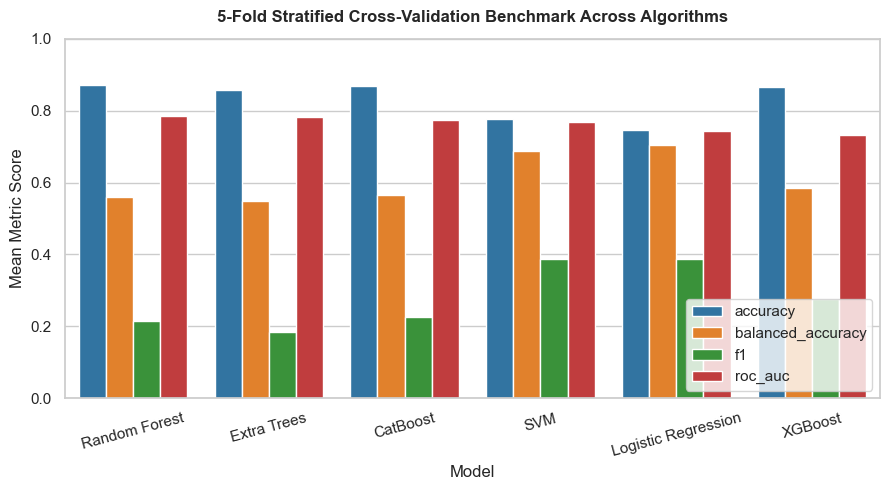

In [4]:
models = {
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Extra Trees": ExtraTreesClassifier(class_weight="balanced", random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42, thread_count=1),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=42),
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
}

cv_results_list = []
model_pipelines = {name: with_preprocessing(model) for name, model in models.items()}

for name, model in model_pipelines.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "balanced_accuracy", "f1", "roc_auc"],
        n_jobs=1,
    )
    cv_results_list.append({
        "model": name,
        "accuracy": float(scores["test_accuracy"].mean()),
        "balanced_accuracy": float(scores["test_balanced_accuracy"].mean()),
        "f1": float(scores["test_f1"].mean()),
        "roc_auc": float(scores["test_roc_auc"].mean()),
    })

results_df = pd.DataFrame(cv_results_list).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(results_df)

# Save cross-validation results table
results_df.to_csv(RESULTS_TAB_DIR / "model_cross_validation_results.csv", index=False)

# Multi-metric comparison bar plot
metric_melted = results_df.melt(
    id_vars="model",
    value_vars=["accuracy", "balanced_accuracy", "f1", "roc_auc"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 5))
sns.barplot(data=metric_melted, x="model", y="Score", hue="Metric", palette="tab10")
plt.title("5-Fold Stratified Cross-Validation Benchmark Across Algorithms", fontsize=12, fontweight="bold", pad=12)
plt.ylabel("Mean Metric Score")
plt.xlabel("Model")
plt.ylim(0, 1.0)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "07_model_cv_comparison.png", dpi=300)
plt.show()


## 5. Random Forest Hyperparameter Optimization

We optimize the Random Forest classifier using `GridSearchCV` on the training split across:
- `n_estimators`: [100, 200, 300, 500]
- `max_depth`: [None, 5, 10, 20]
- `min_samples_split`: [2, 5, 10]
- `min_samples_leaf`: [1, 2, 4]
- `max_features`: ["sqrt", "log2"]


Optimal Hyperparameters: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
Best Cross-Validation ROC-AUC: 0.7852


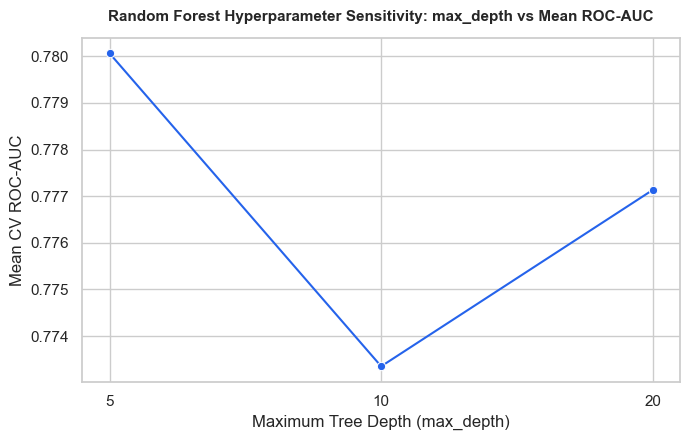

In [5]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"],
}

rf_search = GridSearchCV(
    estimator=with_preprocessing(
        RandomForestClassifier(class_weight="balanced", random_state=42)
    ),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)

rf_search.fit(X_train, y_train)

best_pipeline = rf_search.best_estimator_
print(f"Optimal Hyperparameters: {rf_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC: {rf_search.best_score_:.4f}")

# Save best model summary
best_model_summary = pd.DataFrame([{
    "model": "Random Forest (Optimized)",
    "best_cv_roc_auc": rf_search.best_score_,
    "best_params": str(rf_search.best_params_),
}])
best_model_summary.to_csv(RESULTS_TAB_DIR / "best_model_summary.csv", index=False)

# Hyperparameter sensitivity: max_depth vs ROC-AUC
grid_res = pd.DataFrame(rf_search.cv_results_)
grid_res["max_depth_str"] = grid_res["param_classifier__max_depth"].astype(str)

plt.figure(figsize=(7, 4.5))
sns.lineplot(data=grid_res, x="max_depth_str", y="mean_test_score", marker="o", color="#2563eb", errorbar=None)
plt.title("Random Forest Hyperparameter Sensitivity: max_depth vs Mean ROC-AUC", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Maximum Tree Depth (max_depth)")
plt.ylabel("Mean CV ROC-AUC")
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "08_hyperparameter_tuning_depth.png", dpi=300)
plt.show()


## 6. Learning Curve Analysis

We assess convergence across training subset increments (10% to 100%) to diagnose bias-variance trade-offs under 5-fold cross-validation.


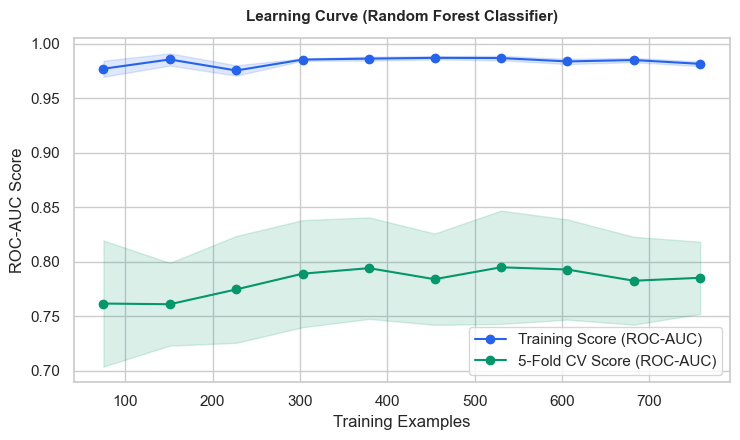

In [6]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=1,
    random_state=42,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(7.5, 4.5))
plt.plot(train_sizes, train_mean, "o-", color="#2563eb", label="Training Score (ROC-AUC)")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#2563eb")
plt.plot(train_sizes, val_mean, "o-", color="#059669", label="5-Fold CV Score (ROC-AUC)")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#059669")

plt.title("Learning Curve (Random Forest Classifier)", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Training Examples")
plt.ylabel("ROC-AUC Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "09_learning_curve.png", dpi=300)
plt.show()


## 7. Held-Out Test Set Evaluation ($N = 237$)

We evaluate generalization on the 20% held-out test set ($N=237$).
Because the active sensitizer class accounts for ~12.3% of the dataset, nominal accuracy alone is driven by majority non-sensitizers. Balanced Accuracy, F1-Score, ROC-AUC, and Average Precision provide a comprehensive evaluation.


,Held-Out Test Score
Accuracy,0.843882
Balanced Accuracy,0.629145
F1-Score,0.350877
ROC-AUC,0.719993
Average Precision (PR-AUC),0.336624


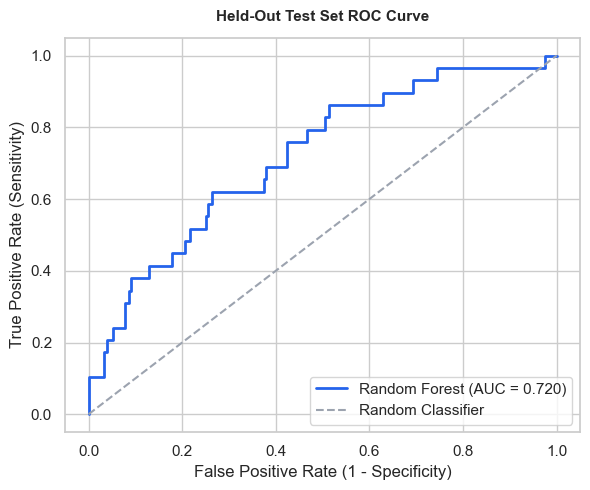

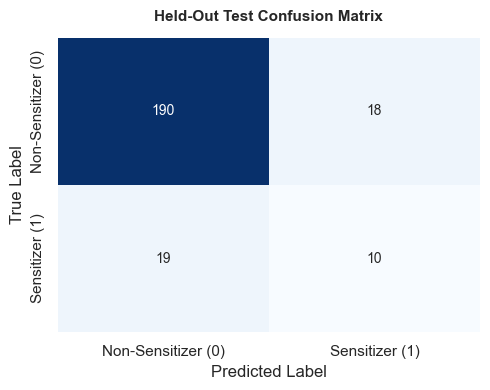

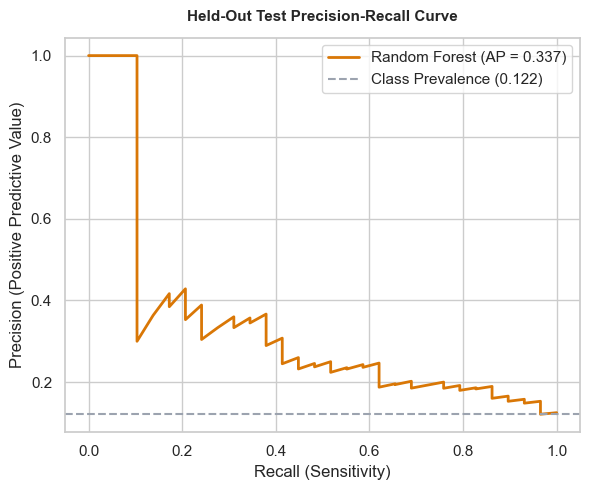

In [7]:
# Generate predictions on held-out test set
rf_probs = best_pipeline.predict_proba(X_test)[:, 1]
rf_preds = best_pipeline.predict(X_test)

test_metrics = {
    "Accuracy": accuracy_score(y_test, rf_preds),
    "Balanced Accuracy": balanced_accuracy_score(y_test, rf_preds),
    "F1-Score": f1_score(y_test, rf_preds),
    "ROC-AUC": roc_auc_score(y_test, rf_probs),
    "Average Precision (PR-AUC)": average_precision_score(y_test, rf_probs),
}

test_metrics_df = pd.DataFrame(test_metrics, index=["Held-Out Test Score"]).T
display(test_metrics_df)
test_metrics_df.rename_axis("metric").reset_index().to_csv(RESULTS_TAB_DIR / "held_out_test_metrics.csv", index=False)

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_test, rf_probs)
roc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#2563eb", lw=2, label=f"Random Forest (AUC = {roc_val:.3f})")
plt.plot([0, 1], [0, 1], color="#9ca3af", linestyle="--", label="Random Classifier")
plt.title("Held-Out Test Set ROC Curve", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "10_test_roc_curve.png", dpi=300)
plt.show()

# 2. Confusion Matrix
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Non-Sensitizer (0)", "Sensitizer (1)"],
            yticklabels=["Non-Sensitizer (0)", "Sensitizer (1)"])
plt.title("Held-Out Test Confusion Matrix", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "11_test_confusion_matrix.png", dpi=300)
plt.show()

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, rf_probs)
ap_val = average_precision_score(y_test, rf_probs)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color="#d97706", lw=2, label=f"Random Forest (AP = {ap_val:.3f})")
plt.axhline(y=y_test.mean(), color="#9ca3af", linestyle="--", label=f"Class Prevalence ({y_test.mean():.3f})")
plt.title("Held-Out Test Precision-Recall Curve", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision (Positive Predictive Value)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "12_test_pr_curve.png", dpi=300)
plt.show()


## 8. Modeled Applicability Domain Assessment

An Isolation Forest is fit using the training partition's descriptor space and then used to flag test compounds relative to that modeled domain. This diagnostic does not use test labels and does not change the classifier or its decision threshold.

Held-Out Test Set Applicability Domain Assessment:
Applicability Domain
Within Modeled AD     216
Outside Modeled AD     21
Name: count, dtype: int64


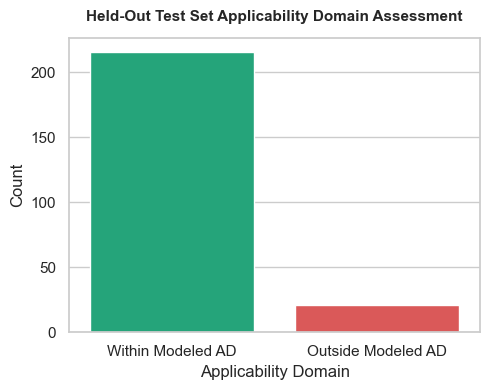

In [8]:
# Modeled Applicability Domain using Isolation Forest
ad_model = IsolationForest(contamination=0.05, random_state=42)
preprocessing = best_pipeline.named_steps["preprocessing"]
X_train_ready = preprocessing.transform(X_train)
X_test_ready = preprocessing.transform(X_test)
ad_model.fit(X_train_ready)

ad_test_flags = ad_model.predict(X_test_ready)
ad_df = pd.DataFrame({"Applicability Domain": np.where(ad_test_flags == 1, "Within Modeled AD", "Outside Modeled AD")})

print("Held-Out Test Set Applicability Domain Assessment:")
print(ad_df["Applicability Domain"].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(data=ad_df, x="Applicability Domain", palette=["#10b981", "#ef4444"])
plt.title("Held-Out Test Set Applicability Domain Assessment", fontsize=11, fontweight="bold", pad=12)
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "14_applicability_domain.png", dpi=300)
plt.show()


## 9. Model Interpretability: Feature Importance & SHAP Analysis

To analyze descriptor attributions:
1. **Gini Impurity Feature Importance (MDI):** Quantifies variance reduction contributed by each descriptor.
2. **SHAP (SHapley Additive exPlanations):** Computes Shapley feature impact using `shap.TreeExplainer` on the held-out test set.


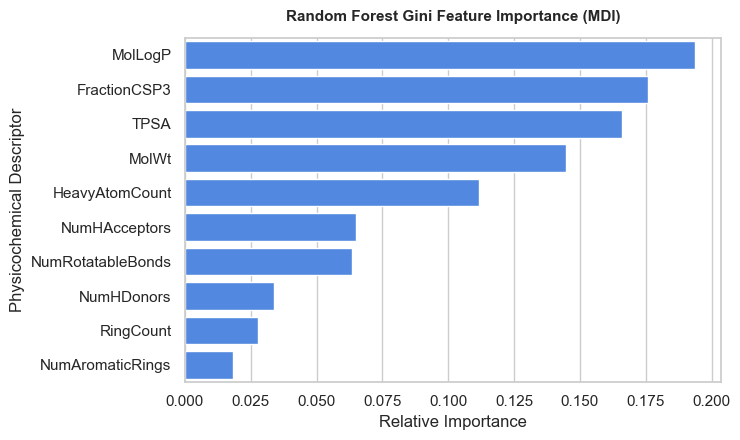

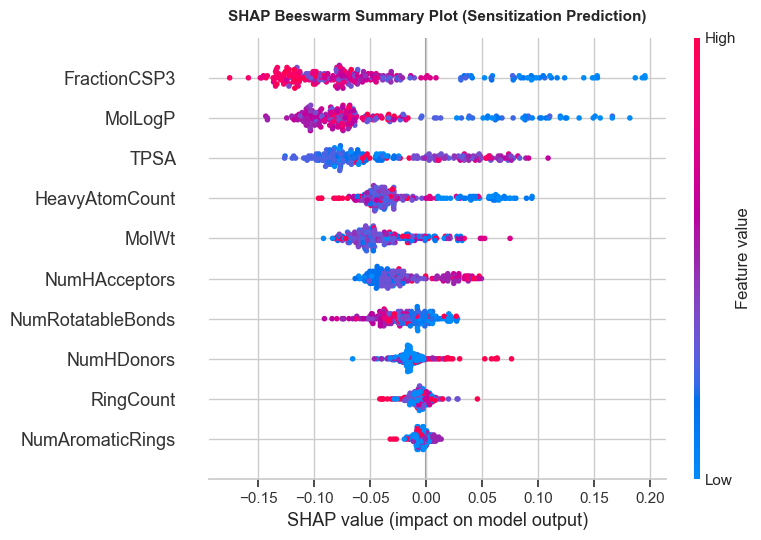

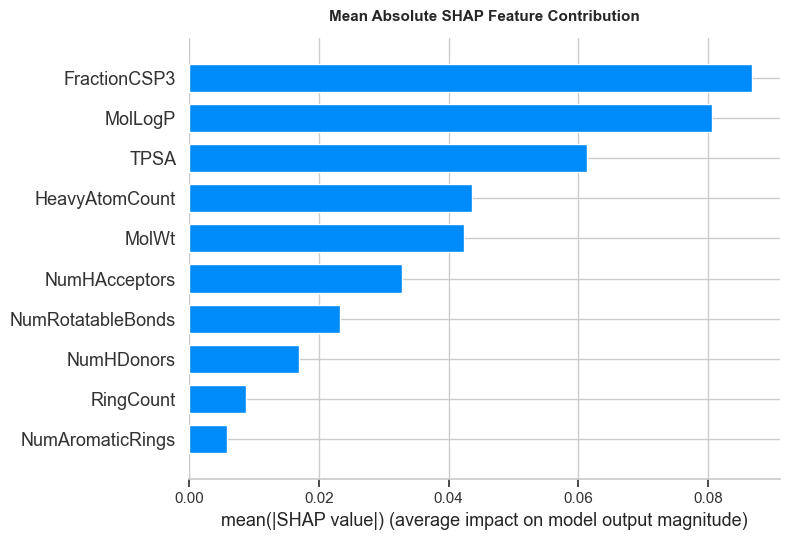

In [9]:
# Get feature names from selector mask
preprocessing = best_pipeline.named_steps["preprocessing"]
variance_mask = preprocessing.named_steps["variance"].get_support()
variance_feature_names = X.columns[variance_mask]
feature_mask = preprocessing.named_steps["selector"].get_support()
selected_feature_names = variance_feature_names[feature_mask]

# 1. Feature Importance (MDI)
importance_df = pd.DataFrame({
    "Feature": selected_feature_names,
    "Importance": best_pipeline.named_steps["classifier"].feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(7.5, 4.5))
sns.barplot(data=importance_df, x="Importance", y="Feature", color="#3b82f6")
plt.title("Random Forest Gini Feature Importance (MDI)", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Relative Importance")
plt.ylabel("Physicochemical Descriptor")
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "15_feature_importance_mdi.png", dpi=300)
plt.show()

# 2. SHAP Interpretability
X_test_selected = pd.DataFrame(
    preprocessing.transform(X_test), columns=selected_feature_names
)
explainer = shap.TreeExplainer(best_pipeline.named_steps["classifier"])
shap_values = explainer(X_test_selected)

# SHAP Beeswarm plot for active sensitization class (index 1)
plt.figure(figsize=(8, 5.5))
shap.plots.beeswarm(shap_values[:, :, 1], max_display=10, show=False)
plt.title("SHAP Beeswarm Summary Plot (Sensitization Prediction)", fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "16_shap_summary_beeswarm.png", dpi=300)
plt.show()

# SHAP Mean Absolute Value bar plot
plt.figure(figsize=(8, 5.5))
shap.summary_plot(shap_values[:, :, 1], X_test_selected, plot_type="bar", show=False)
plt.title("Mean Absolute SHAP Feature Contribution", fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "17_shap_summary_bar.png", dpi=300)
plt.show()


## 10. Model Serialization & Reproduction Verification


In [10]:
# Serialize optimized model artifact
joblib.dump(best_pipeline, MODELS_DIR / "sensitization_pipeline.joblib")
print("Serialized complete preprocessing + Random Forest pipeline.")

# Verify reproduction from disk
loaded_pipeline = joblib.load(MODELS_DIR / "sensitization_pipeline.joblib")
assert np.all(loaded_pipeline.predict(X_test) == best_pipeline.predict(X_test)), "Pipeline prediction mismatch upon reloading!"
print("Model serialization verified successfully.")


Serialized complete preprocessing + Random Forest pipeline.
Model serialization verified successfully.


## 11. Cross-Endpoint Virtual Screening on Skin & Eye Irritation Libraries

We apply the optimized sensitization model as a **virtual screening tool** on external **Skin Irritation** ($N = 200$) and **Eye Irritation** ($N = 327$) compound libraries.
*Note:* This represents in silico computational prioritization and has not been experimentally validated as a cross-endpoint toxicity prediction assay.


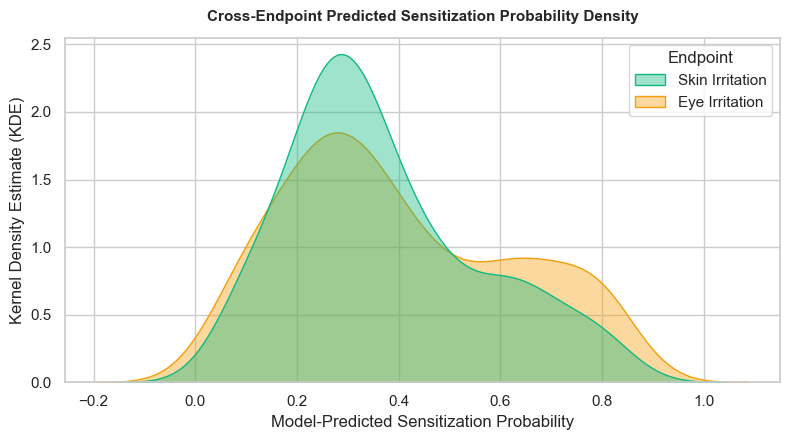

In [11]:
# Load external irritation descriptor datasets
irritation_ext_path = DATA_PROCESSED_DIR / "skin_irritation_descriptors.csv"
eye_ext_path = DATA_PROCESSED_DIR / "eye_irritation_descriptors.csv"

if not irritation_ext_path.exists() or not eye_ext_path.exists():
    raise FileNotFoundError("External descriptor datasets missing in data/processed/. Please execute notebook 01 first.")

irritation_ext = pd.read_csv(irritation_ext_path)
eye_ext = pd.read_csv(eye_ext_path)

# Align feature columns
X_irritation = irritation_ext.reindex(columns=X.columns, fill_value=0)
X_eye = eye_ext.reindex(columns=X.columns, fill_value=0)

# Score the auxiliary cohorts only after sensitization model fitting.
# Their labels are not used by the sensitization model.
irritation_ext["predicted_sensitization_probability"] = best_pipeline.predict_proba(X_irritation)[:, 1]
eye_ext["predicted_sensitization_probability"] = best_pipeline.predict_proba(X_eye)[:, 1]

# Combine for cross-endpoint density comparison
cross_endpoint_df = pd.DataFrame({
    "Predicted Probability": np.concatenate([irritation_ext["predicted_sensitization_probability"], eye_ext["predicted_sensitization_probability"]]),
    "Endpoint": ["Skin Irritation"] * len(irritation_ext) + ["Eye Irritation"] * len(eye_ext)
})

plt.figure(figsize=(8, 4.5))
sns.kdeplot(data=cross_endpoint_df, x="Predicted Probability", hue="Endpoint", fill=True, palette={"Skin Irritation": "#10b981", "Eye Irritation": "#f59e0b"}, common_norm=False, alpha=0.4)
plt.title("Cross-Endpoint Predicted Sensitization Probability Density", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Model-Predicted Sensitization Probability")
plt.ylabel("Kernel Density Estimate (KDE)")
plt.tight_layout()
plt.savefig(RESULTS_FIG_DIR / "18_cross_endpoint_probability_kde.png", dpi=300)
plt.show()


## 12. Structural & Physicochemical Property Profiling of Screened Compounds

We profile compounds from the external irritation datasets based on model-predicted sensitization probability:
- **High Predicted Probability Subgroup:** Model-Predicted Probability $> 0.70$
- **Low Predicted Probability Subgroup:** Model-Predicted Probability $< 0.10$


,"High Predicted Probability (P > 0.70, N=62)","Low Predicted Probability (P < 0.10, N=30)"
MolWt,128.021,236.724
MolLogP,0.058,2.544
TPSA,50.298,51.292
FractionCSP3,0.189,0.587
NumAromaticRings,0.484,0.867
NumRotatableBonds,0.952,5.100
HeavyAtomCount,7.484,16.133
RingCount,0.565,0.933


Representative Screened Molecular Structures with High Predicted Sensitization Probability (P > 0.70):


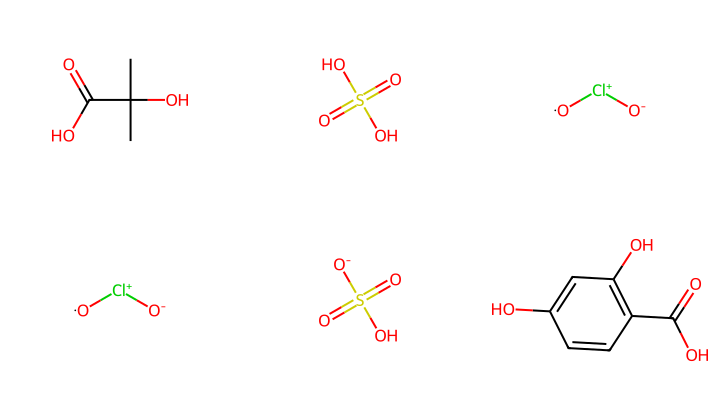

Representative Screened Molecular Structures with Low Predicted Sensitization Probability (P < 0.10):


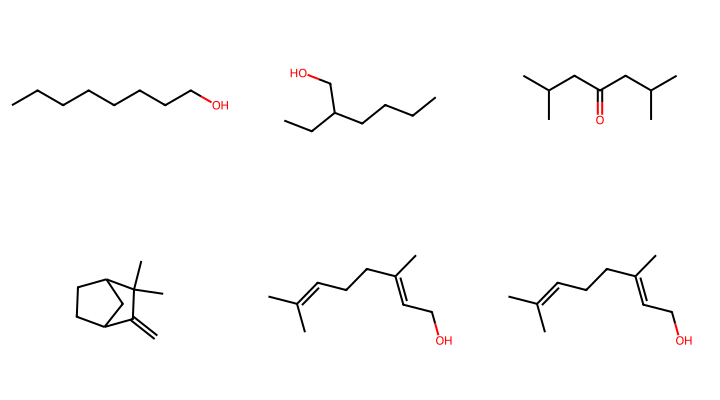

In [12]:
# Load combined external dataset
combined_ext_path = DATA_PROCESSED_DIR / "external_combined_descriptors.csv"
combined_ext = pd.read_csv(combined_ext_path)
combined_ext["predicted_sensitization_probability"] = np.concatenate([irritation_ext["predicted_sensitization_probability"], eye_ext["predicted_sensitization_probability"]])

# Subgroup partitioning
high_pred = combined_ext[combined_ext["predicted_sensitization_probability"] > 0.70].copy()
low_pred = combined_ext[combined_ext["predicted_sensitization_probability"] < 0.10].copy()

profile_cols = ["MolWt", "MolLogP", "TPSA", "FractionCSP3", "NumAromaticRings", "NumRotatableBonds", "HeavyAtomCount", "RingCount"]

comparison_df = pd.DataFrame({
    "High Predicted Probability (P > 0.70, N={})".format(len(high_pred)): high_pred[profile_cols].mean(),
    "Low Predicted Probability (P < 0.10, N={})".format(len(low_pred)): low_pred[profile_cols].mean(),
})

display(comparison_df.round(3))
comparison_df.round(3).to_csv(RESULTS_TAB_DIR / "high_risk_vs_low_risk_descriptors.csv")

# 2D Molecular structures of top high-probability compounds
top_high_smiles = high_pred.sort_values("predicted_sensitization_probability", ascending=False)["standardized_smi"].dropna().head(6)
high_mols = [Chem.MolFromSmiles(s) for s in top_high_smiles if Chem.MolFromSmiles(s) is not None]

print("Representative Screened Molecular Structures with High Predicted Sensitization Probability (P > 0.70):")
img_high = Draw.MolsToGridImage(high_mols, molsPerRow=3, subImgSize=(240, 200), returnPNG=False)
display(img_high)

# 2D Molecular structures of representative low-probability compounds
top_low_smiles = low_pred.sort_values("predicted_sensitization_probability", ascending=True)["standardized_smi"].dropna().head(6)
low_mols = [Chem.MolFromSmiles(s) for s in top_low_smiles if Chem.MolFromSmiles(s) is not None]

print("Representative Screened Molecular Structures with Low Predicted Sensitization Probability (P < 0.10):")
img_low = Draw.MolsToGridImage(low_mols, molsPerRow=3, subImgSize=(240, 200), returnPNG=False)
display(img_low)


## 13. Summary of Analysis

The selected Random Forest is evaluated on a stratified held-out partition from the curated skin-sensitization cohort. Cross-validation results are used for model comparison and hyperparameter selection; held-out test metrics are reported separately at the fixed 0.50 threshold. Auxiliary irritation cohorts are scored descriptively after model fitting and are not validation datasets for sensitization. Results do not establish clinical validity or performance on external populations.